In [2]:
import pandas as pd
import json
import re

# Step 1: Load the JSON lines file (one tweet per line)
file_path = "psl_tweet_data.csv"  # Update this path if needed

valid_tweets = []
with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        line = line.strip()
        if line:
            try:
                tweet = json.loads(line)
                valid_tweets.append(tweet)
            except json.JSONDecodeError:
                continue

# Step 2: Extract required and useful fields
extracted_data = []
for tweet in valid_tweets:
    user = tweet.get("user", {})
    entities = tweet.get("entities", {})

    message = tweet.get("full_text") or tweet.get("text") or ""

    extracted_data.append({
        # Required fields (per project)
        "tweet_date": tweet.get("created_at"),
        "tweet_id": tweet.get("id_str") or tweet.get("id"),
        "message": message,
        "user_id": user.get("id_str") or user.get("id"),
        "followers": user.get("followers_count"),
        "friends": user.get("friends_count"),
        "favorites": user.get("favourites_count"),
        "statuses": user.get("statuses_count"),
        "account_created": user.get("created_at"),
        "location": user.get("location"),

        # Additional useful fields
        "lang": tweet.get("lang"),
        "retweet_count": (
            tweet.get("retweeted_status", {}).get("retweet_count")
            if tweet.get("retweeted_status")
            else tweet.get("retweet_count")
        ),
        "favorite_count": tweet.get("favorite_count"),
        "source": tweet.get("source"),
        "in_reply_to_status_id": tweet.get("in_reply_to_status_id"),
        "possibly_sensitive": tweet.get("possibly_sensitive"),
        "retweeted": bool(tweet.get("retweeted_status")),
        "hashtags": [tag.get("text") for tag in entities.get("hashtags", [])],
        "user_mentions": [mention.get("screen_name") for mention in entities.get("user_mentions", [])],
        "urls": [u.get("expanded_url") for u in entities.get("urls", [])]
    })

# Step 3: Create DataFrame
df_cleaned = pd.DataFrame(extracted_data)

# Step 4: Clean tweet message (remove URLs, mentions, hashtags, extra whitespace)
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)       # Remove URLs
    text = re.sub(r"@\w+", "", text)          # Remove mentions
    text = re.sub(r"#", "", text)             # Remove hashtag symbols
    text = re.sub(r"\s+", " ", text).strip()  # Normalize whitespace
    return text

df_cleaned["clean_message"] = df_cleaned["message"].apply(clean_text)

# Step 5: Optional – Convert datetime strings to datetime objects
df_cleaned["tweet_date"] = pd.to_datetime(df_cleaned["tweet_date"], errors='coerce')
df_cleaned["account_created"] = pd.to_datetime(df_cleaned["account_created"], errors='coerce')

# Step 6: Preview
print(df_cleaned[["message", "clean_message", "retweet_count"]].head())

# Step 7: Save cleaned data
df_cleaned.to_csv("tweets_cleaned_full.csv", index=False)
print("✅ Cleaned data saved to 'tweets_cleaned_full.csv'")



/tmp/ipykernel_18602/2612843285.py:72: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned["tweet_date"] = pd.to_datetime(df_cleaned["tweet_date"], errors='coerce')
/tmp/ipykernel_18602/2612843285.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned["account_created"] = pd.to_datetime(df_cleaned["account_created"], errors='coerce')


                                             message  \
0  RT @anussaeed1: پی ایس ایل کے فائنل سے زیادہ م...   
1  RT @Arham_Apsacs: Asif afridi and Final Matche...   
2  RT @Uxmn63: Willey to Ghulam, no run\nDropped ...   
3        Weise is on the crease😍😍😍\n#PSLFinal #LQvMS   
4  RT @Iam_Mian: Picture of the day ❤️😻 #PSLFinal...   

                                       clean_message  retweet_count  
0  RT : پی ایس ایل کے فائنل سے زیادہ مجھے اس بات ...            154  
1  RT : Asif afridi and Final Matches - what a Ma...              1  
2  RT : Willey to Ghulam, no run Dropped at point...              4  
3           Weise is on the crease😍😍😍 PSLFinal LQvMS              0  
4               RT : Picture of the day ❤️😻 PSLFinal             10  
✅ Cleaned data saved to 'tweets_cleaned_full.csv'


In [3]:
!pip install deep-translator
from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except:
        return text  # fallback

df_cleaned['translated_message'] = df_cleaned['clean_message'].apply(translate_to_english)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.0 MB/s eta 0:00:00


In [4]:
df_cleaned.to_csv("tweets_cleaned_translated.csv", index=False)


In [5]:
!pip install vaderSentiment
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load your translated tweet file
df = pd.read_csv("tweets_cleaned_translated.csv")

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to calculate sentiment score and label
def analyze_sentiment(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0.0, "Neutral"

    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return score, "Positive"
    elif score <= -0.05:
        return score, "Negative"
    else:
        return score, "Neutral"

# Apply sentiment analysis
df[['sentiment_score', 'sentiment_category']] = df['translated_message'].apply(
    lambda x: pd.Series(analyze_sentiment(x))
)

# Save to new CSV
df.to_csv("tweets_with_sentiment.csv", index=False)
print("✅ Sentiment scores added and saved to 'tweets_with_sentiment.csv'")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
✅ Sentiment scores added and saved to 'tweets_with_sentiment.csv'


In [6]:
# Total number of tweets
total_tweets = len(df_cleaned)
print(f"1. Total number of tweets: {total_tweets}")

# Number of retweets
num_retweets = df_cleaned["retweeted"].sum()
print(f"2. Number of retweets: {num_retweets}")

# Total number of unique users
unique_users = df_cleaned["user_id"].nunique()
print(f"3. Total number of unique users: {unique_users}")

# Number of tweets containing a URL
tweets_with_urls = df_cleaned["urls"].apply(lambda x: len(x) > 0 if isinstance(x, list) else False).sum()
print(f"4. Number of tweets containing a URL: {tweets_with_urls}")

# Number of tweets that are replies (starting with "@")
tweets_that_are_replies = df_cleaned["message"].str.strip().str.startswith("@").sum()
print(f"5. Number of tweets that are replies: {tweets_that_are_replies}")


1. Total number of tweets: 5866
2. Number of retweets: 2006
3. Total number of unique users: 3560
4. Number of tweets containing a URL: 483
5. Number of tweets that are replies: 130


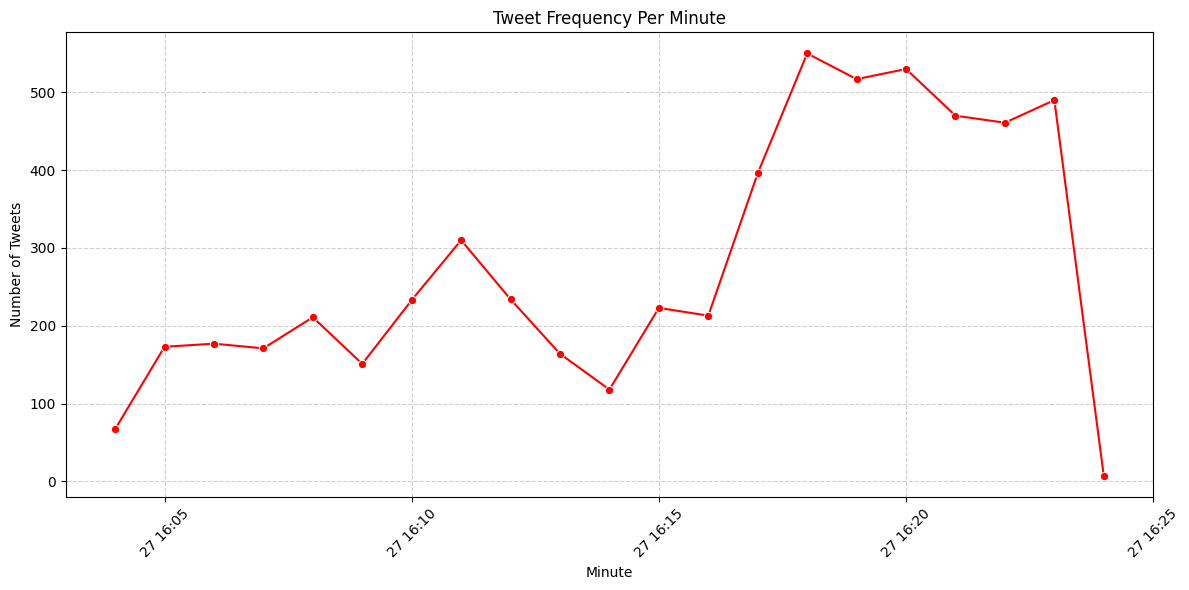

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df['tweet_date'] = pd.to_datetime(df['tweet_date'], errors='coerce')
df['minute'] = df['tweet_date'].dt.floor('min')

tweets_per_minute = df.groupby('minute').size().reset_index(name='tweet_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=tweets_per_minute, x='minute', y='tweet_count', marker='o', color='red')
plt.title("Tweet Frequency Per Minute")
plt.xlabel("Minute")
plt.ylabel("Number of Tweets")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_18602/335187448.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_locations, y='location', x='count', palette='rocket')


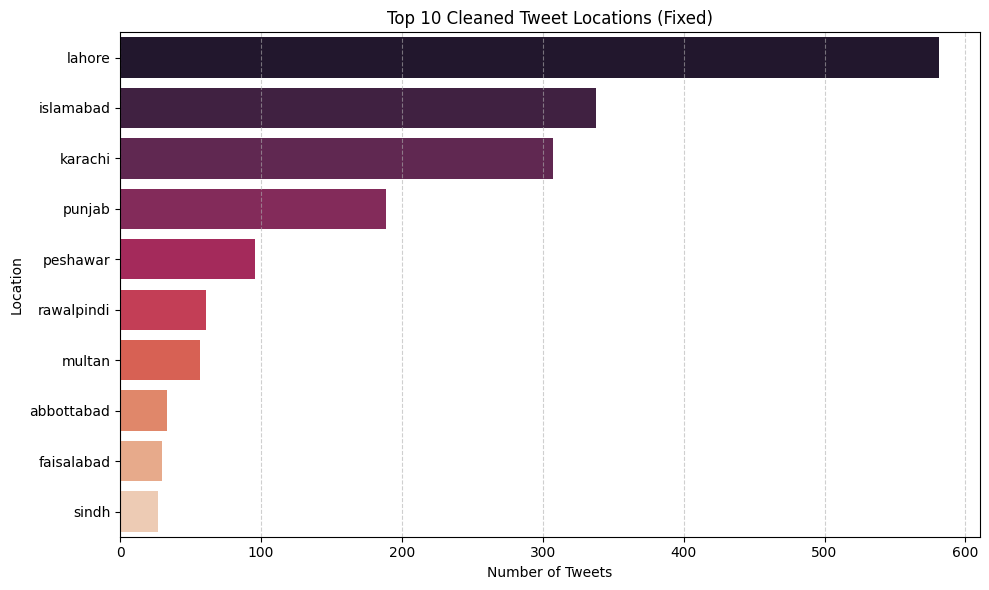

In [8]:
# Step 1: Clean location as before
df['location_cleaned'] = df['location'].fillna('').str.lower().str.strip()
df['location_cleaned'] = df['location_cleaned'].apply(lambda x: re.sub(r'[^\w\s,]', '', x))
df = df[df['location_cleaned'].str.contains(r'^[a-z\s,]+$', na=False)]
df['location_cleaned'] = (
    df['location_cleaned'].str.replace('pakistan', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Step 2: Remove empty strings
df = df[df['location_cleaned'] != '']

# Optional: corrections
city_corrections = {
    'lahore': 'lahore', 'karachi': 'karachi', 'islamabad': 'islamabad',
    'rawalpindi': 'rawalpindi', 'peshawar': 'peshawar', 'multan': 'multan',
    'punjab': 'punjab', 'gujranwala': 'gujranwala', 'abbottabad': 'abbottabad',
    'sialkot': 'sialkot'
}
df['location_cleaned'] = df['location_cleaned'].replace(city_corrections)

# Step 3: Plot after filtering
top_locations = df['location_cleaned'].value_counts().nlargest(10).reset_index()
top_locations.columns = ['location', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_locations, y='location', x='count', palette='rocket')
plt.title("Top 10 Cleaned Tweet Locations (Fixed)")
plt.xlabel("Number of Tweets")
plt.ylabel("Location")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()





/tmp/ipykernel_18602/4268499336.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sources, y='source', x='count', palette='flare')


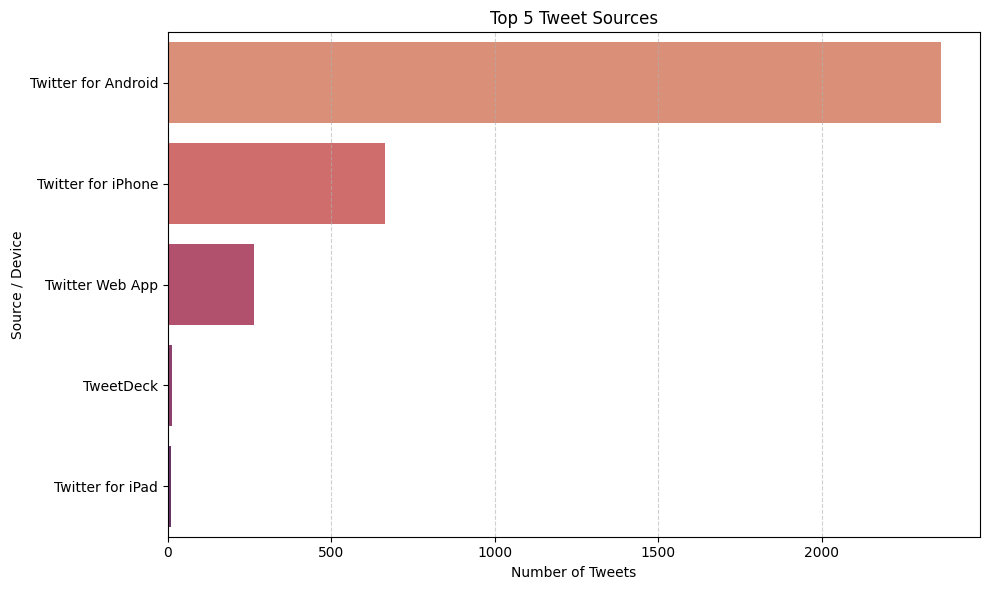

In [9]:
def clean_source(raw_html):
    if pd.isna(raw_html):
        return 'Unknown'
    match = re.search(r'>(.*?)<', raw_html)
    return match.group(1) if match else raw_html

df['source_cleaned'] = df['source'].apply(clean_source)

top_sources = df['source_cleaned'].value_counts().nlargest(5).reset_index()
top_sources.columns = ['source', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_sources, y='source', x='count', palette='flare')
plt.title("Top 5 Tweet Sources")
plt.xlabel("Number of Tweets")
plt.ylabel("Source / Device")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


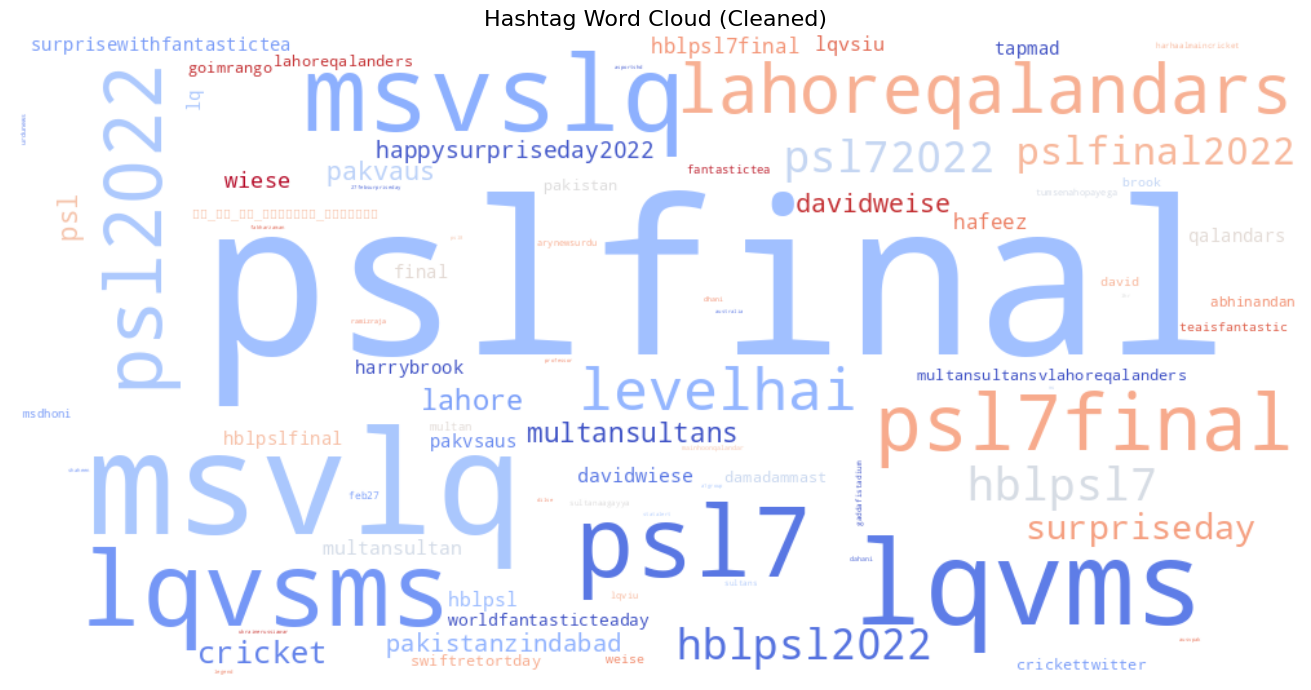

In [12]:
import ast
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Parse stringified lists to actual lists
def parse_hashtags(cell):
    if isinstance(cell, list):
        return cell
    try:
        return ast.literal_eval(cell)
    except:
        return []

# Apply parsing (use df_cleaned instead of df)
hashtags_series = df_cleaned['hashtags'].dropna().apply(parse_hashtags).explode()

# Clean hashtags properly
hashtags_cleaned = hashtags_series.dropna()
hashtags_cleaned = hashtags_cleaned[hashtags_cleaned.apply(lambda x: isinstance(x, str))]
hashtags_cleaned = hashtags_cleaned.str.strip().str.lower()
hashtags_cleaned = hashtags_cleaned[hashtags_cleaned != ""]

# Step 2: Count hashtags
hashtag_counts = Counter(hashtags_cleaned)

# Step 3: Generate word cloud
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='coolwarm')\
    .generate_from_frequencies(hashtag_counts)

# Step 4: Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Hashtag Word Cloud (Cleaned)", fontsize=16)
plt.tight_layout()
plt.show()




/tmp/ipykernel_18602/2934595634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_category', palette='Set2')


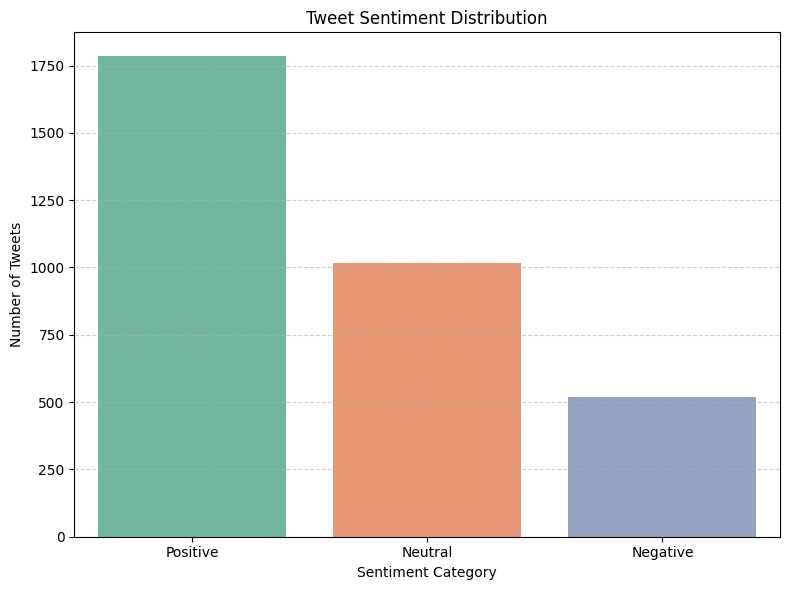

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment_category', palette='Set2')
plt.title("Tweet Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Tweets")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


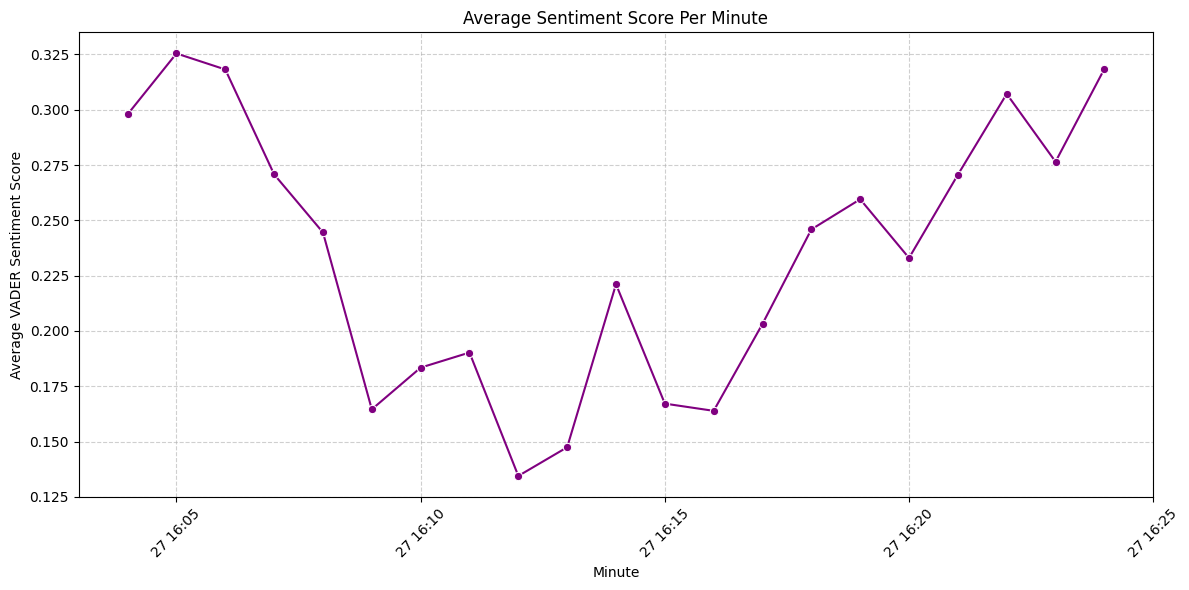

In [14]:
df['tweet_date'] = pd.to_datetime(df['tweet_date'], errors='coerce')
df['minute'] = df['tweet_date'].dt.floor('min')

sentiment_over_time = df.groupby('minute')['sentiment_score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sentiment_over_time, x='minute', y='sentiment_score', marker='o', color='purple')
plt.title("Average Sentiment Score Per Minute")
plt.xlabel("Minute")
plt.ylabel("Average VADER Sentiment Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_18602/82862049.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_by_city, y='location_cleaned', x='sentiment_score', palette='Spectral')


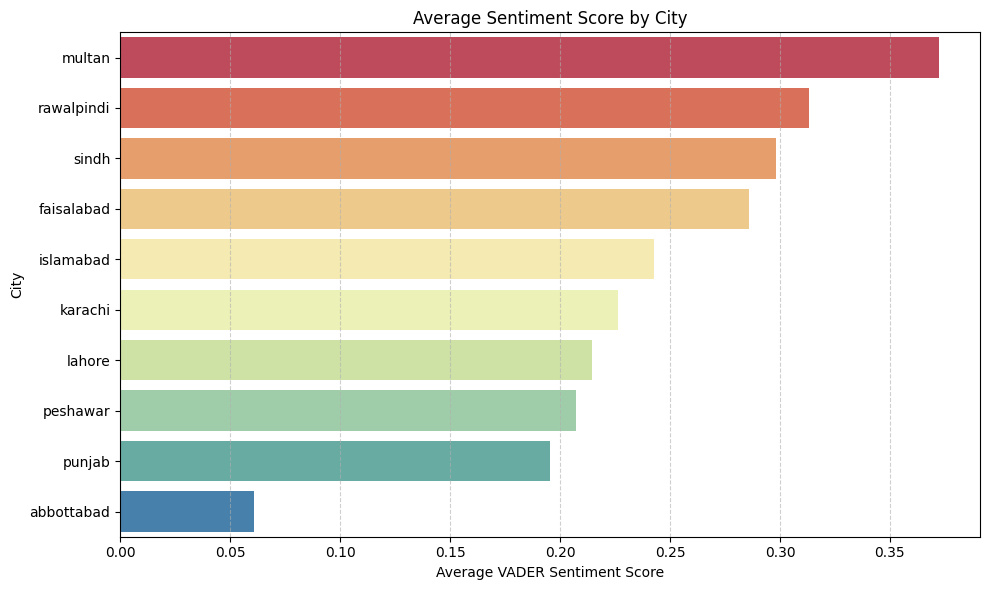

In [15]:
# Ensure location is cleaned
top_locations = (
    df['location_cleaned'].value_counts()
    .nlargest(10)
    .index
)

df_top_locations = df[df['location_cleaned'].isin(top_locations)]

# Group by location and compute average sentiment score
sentiment_by_city = (
    df_top_locations.groupby('location_cleaned')['sentiment_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=sentiment_by_city, y='location_cleaned', x='sentiment_score', palette='Spectral')
plt.title("Average Sentiment Score by City")
plt.xlabel("Average VADER Sentiment Score")
plt.ylabel("City")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



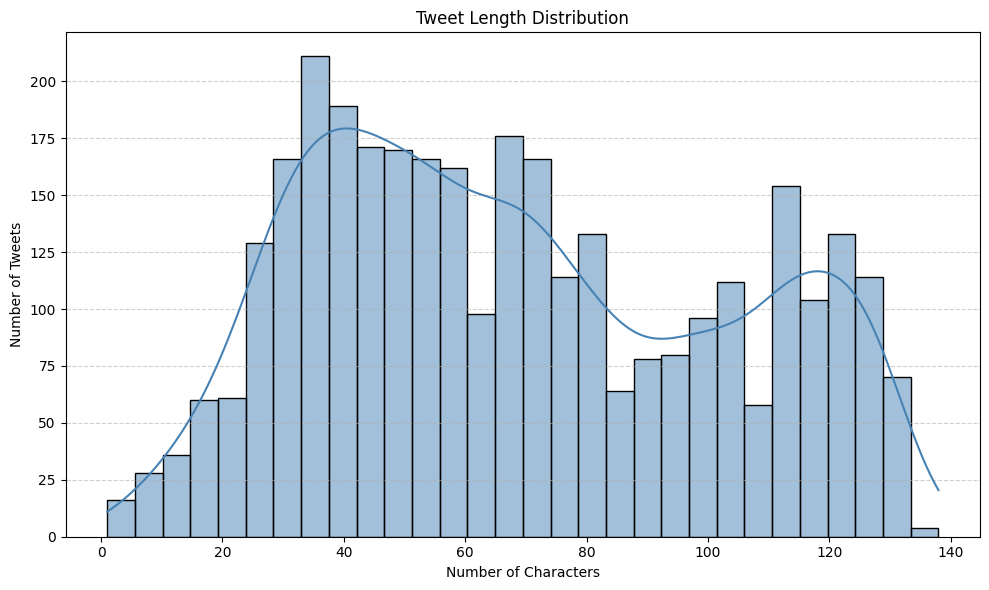

/tmp/ipykernel_18602/904851187.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment_category', y='tweet_length', palette='Set2')


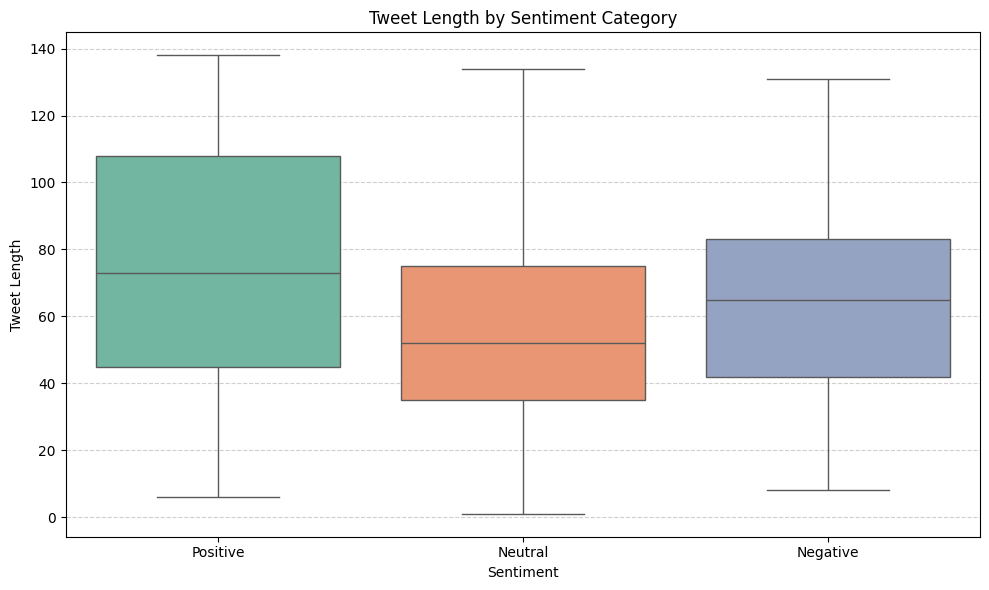

In [16]:
# Step 1: Compute length of each tweet (in characters)
df['tweet_length'] = df['clean_message'].astype(str).str.len()

# Step 2: Plot histogram of tweet lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['tweet_length'], bins=30, kde=True, color='steelblue')
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment_category', y='tweet_length', palette='Set2')
plt.title("Tweet Length by Sentiment Category")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



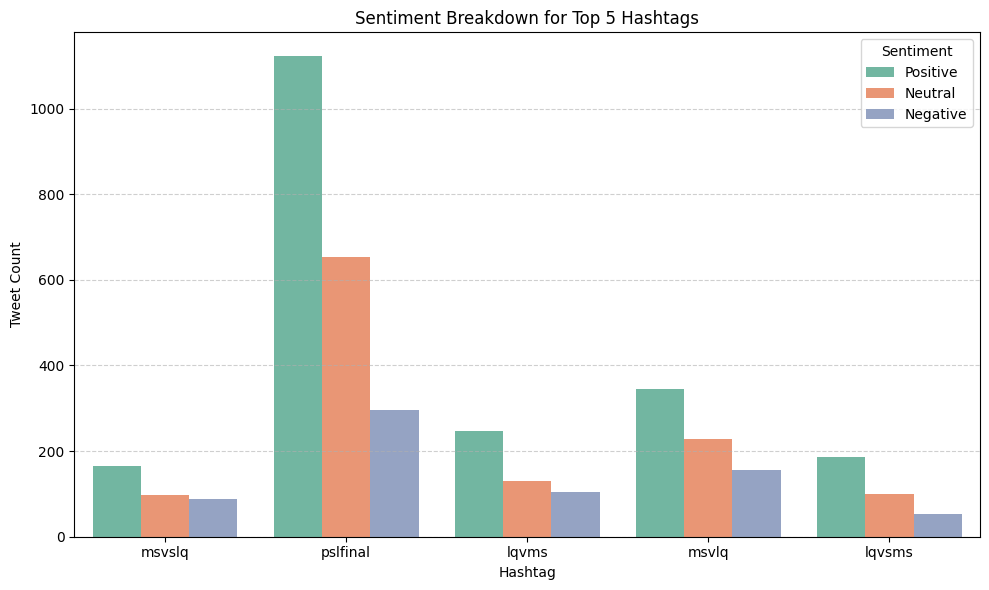

In [17]:
import ast

# Step 1: Parse hashtags properly
def parse_hashtags(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

df['hashtags_cleaned'] = df['hashtags'].dropna().apply(parse_hashtags)

# Explode hashtags for proper grouping
df_hashtags = df.explode('hashtags_cleaned')
df_hashtags['hashtags_cleaned'] = df_hashtags['hashtags_cleaned'].str.lower().str.strip()
df_hashtags = df_hashtags[df_hashtags['hashtags_cleaned'] != '']

# Get top 5 hashtags
top_hashtags = df_hashtags['hashtags_cleaned'].value_counts().nlargest(5).index
df_top_hashtags = df_hashtags[df_hashtags['hashtags_cleaned'].isin(top_hashtags)]

# Plot: Sentiment category per top hashtag
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top_hashtags, x='hashtags_cleaned', hue='sentiment_category', palette='Set2')
plt.title("Sentiment Breakdown for Top 5 Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Tweet Count")
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


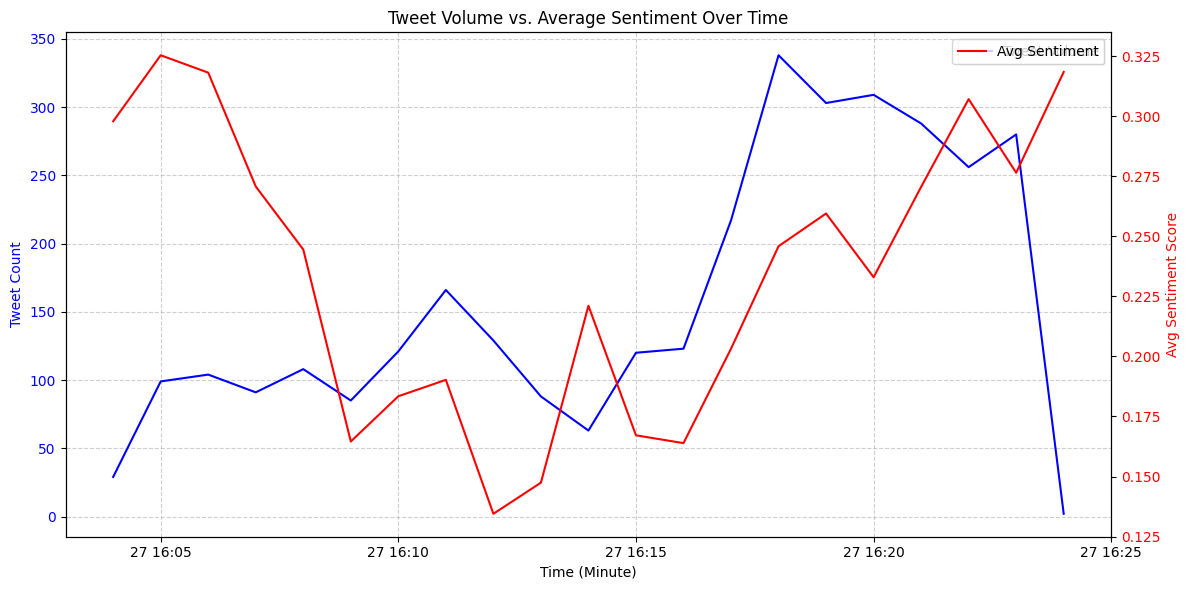

In [18]:
# Ensure tweet_date is datetime and create time buckets
df['tweet_date'] = pd.to_datetime(df['tweet_date'], errors='coerce')
df['minute'] = df['tweet_date'].dt.floor('min')

# Group: tweet count and average sentiment per minute
volume_sentiment = df.groupby('minute').agg(
    tweet_count=('tweet_id', 'count'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Tweet count on left axis
sns.lineplot(data=volume_sentiment, x='minute', y='tweet_count', ax=ax1, color='blue', label='Tweet Volume')
ax1.set_ylabel('Tweet Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Sentiment on right axis
ax2 = ax1.twinx()
sns.lineplot(data=volume_sentiment, x='minute', y='avg_sentiment', ax=ax2, color='red', label='Avg Sentiment')
ax2.set_ylabel('Avg Sentiment Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and grid
plt.title("Tweet Volume vs. Average Sentiment Over Time")
ax1.set_xlabel("Time (Minute)")
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()




In [20]:
import json

def extract_actual_favorite_count(tweet):
    # If it's a retweet, get the like count from the original tweet
    if 'retweeted_status' in tweet:
        return tweet['retweeted_status'].get('favorite_count', 0)
    # Otherwise get it from this tweet itself
    return tweet.get('favorite_count', 0)

# Example: processing a JSON lines file
valid_tweets = []
file_path = "G_1 (1).csv"

with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
    for line in file:
        line = line.strip()
        if line:
            try:
                tweet = json.loads(line)
                tweet['actual_favorite_count'] = extract_actual_favorite_count(tweet)
                valid_tweets.append(tweet)
            except json.JSONDecodeError:
                continue


📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.43      0.54       164
     Neutral       0.70      0.74      0.72       361
    Positive       0.80      0.86      0.83       649

    accuracy                           0.76      1174
   macro avg       0.75      0.68      0.70      1174
weighted avg       0.76      0.76      0.76      1174



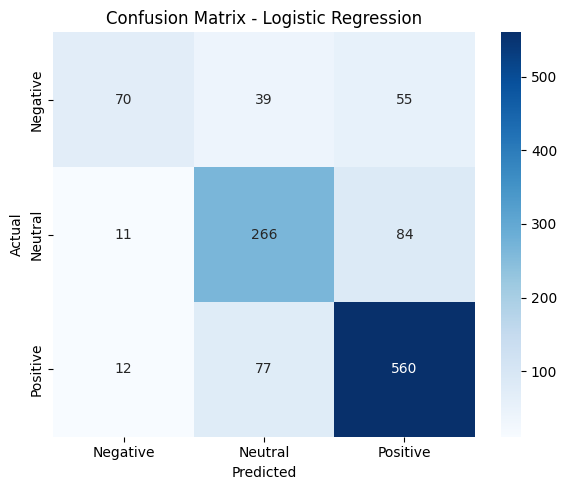

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load your dataset
df = pd.read_csv('/content/tweets_with_sentiment.csv')  # Update path if needed

# Step 2: Define features and labels
X = df['translated_message'].fillna('')
y = df['sentiment_category'].fillna('Neutral')

# Step 3: Convert text into TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Step 5: Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Step 7: Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
labels = model.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(conf_matrix, index=labels, columns=labels),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


📊 Cluster Summary (Log-Transformed):
              followers  friends  favorites  statuses
user_cluster                                         
0              26209.55  2575.35   69438.95  58170.11
1                 65.42   109.59     781.82    639.11
2                666.42   504.64   11909.38   9075.92


/tmp/ipykernel_18602/2075117495.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


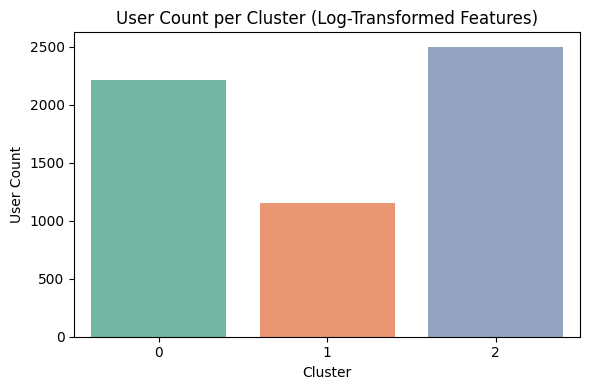

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Log-transform skewed features
features = ['followers', 'friends', 'favorites', 'statuses']
df_log = df[features].dropna().copy()
df_log = df_log.apply(lambda x: np.log1p(x))  # Safely handle 0s

# Step 2: Scale the transformed features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

# Step 3: KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_log['user_cluster'] = kmeans.fit_predict(X_scaled)

# Step 4: Add cluster labels back to main DataFrame
df_result = df.loc[df_log.index].copy()
df_result['user_cluster'] = df_log['user_cluster'].values

# Step 5: Summary of each cluster
summary = df_result.groupby('user_cluster')[features].mean().round(2)
print("📊 Cluster Summary (Log-Transformed):")
print(summary)

# Step 6: Visualize user count per cluster
cluster_counts = df_result['user_cluster'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.title("User Count per Cluster (Log-Transformed Features)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.tight_layout()
plt.show()


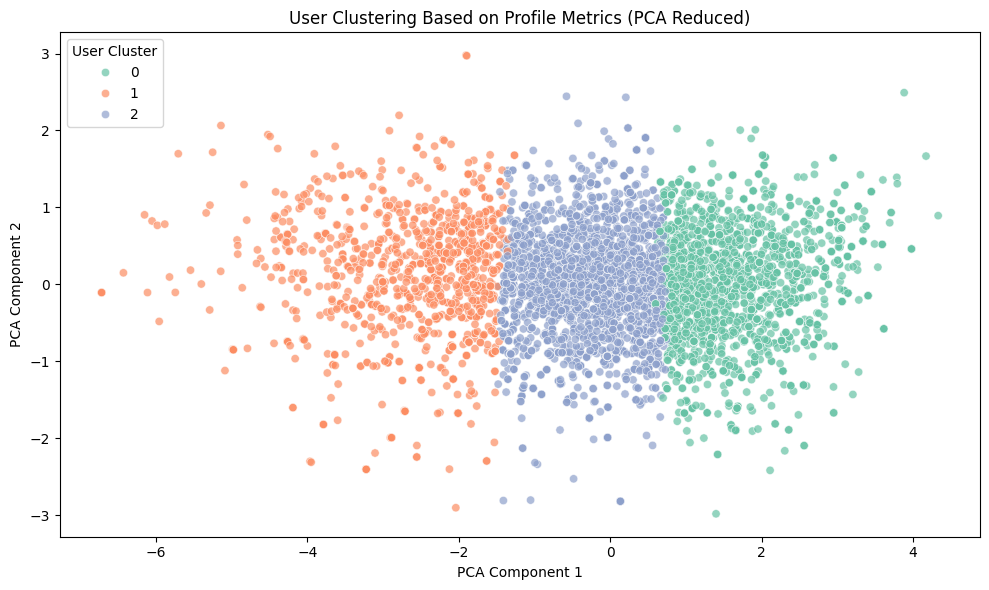

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/tweets_with_sentiment.csv')

# Select numerical user-based columns
user_features = df[['followers', 'friends', 'favorites', 'statuses']].copy()

# Log-transform to reduce skewness
user_features_log = np.log1p(user_features)

# Standardize
scaler = StandardScaler()
user_features_scaled = scaler.fit_transform(user_features_log)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
user_features_pca = pca.fit_transform(user_features_scaled)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(user_features_scaled)

# Attach cluster info for plotting
df['user_cluster'] = clusters
df['pca1'] = user_features_pca[:, 0]
df['pca2'] = user_features_pca[:, 1]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='user_cluster', palette='Set2', alpha=0.7)
plt.title("User Clustering Based on Profile Metrics (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="User Cluster")
plt.tight_layout()
plt.show()
